In [1]:
from numba import cuda, float32
import threading

import math
import numpy as np
import matplotlib.pyplot as plt
from time import time



In [2]:
KSIZE = 7
RADIUS = KSIZE // 2

In [13]:
def make_gaussian_kernel(ksize=KSIZE, sigma=1.5):
    ax = np.arange(ksize) - ksize // 2
    xx, yy = np.meshgrid(ax, ax)
    k = np.exp(-(xx**2 + yy**2) / (2.0 * sigma**2))
    k /= k.sum()
    return k.astype(np.float32)

@cuda.jit
def grayscale_gpu_2d(src, dst):
    x, y = cuda.grid(2)
    if y < src.shape[0] and x < src.shape[1]:
        r = np.int32(src[y, x, 0])
        g_ = np.int32(src[y, x, 1])
        b = np.int32(src[y, x, 2])
        g = np.uint8((r + g_ + b) / 3)
        dst[y, x, 0] = g
        dst[y, x, 1] = g
        dst[y, x, 2] = g

def run_grayscale_gpu_2d(img, block_size=(8, 8)):
    img_c = np.ascontiguousarray(img)
    gray = np.zeros_like(img_c)
    height, width = img_c.shape[0], img_c.shape[1]
    blocks_per_grid = (math.ceil(width / block_size[0]),
                       math.ceil(height / block_size[1]))
    d_img = cuda.to_device(img_c)
    d_gray = cuda.to_device(gray)
    start = time()
    grayscale_gpu_2d[blocks_per_grid, block_size](d_img, d_gray)
    cuda.synchronize()
    end = time()
    return d_gray.copy_to_host(), end - start



@cuda.jit
def gaussian_blur_global(src, dst, filt):
    x, y = cuda.grid(2)
    h, w = src.shape[0], src.shape[1]
    if y < h and x < w:
        for c in range(3):
            acc = float32(0.0)
            for i in range(KSIZE):
                for j in range(KSIZE):
                    yy = min(max(y + i - RADIUS, 0), h - 1)
                    xx = min(max(x + j - RADIUS, 0), w - 1)
                    acc += src[yy, xx, c] * filt[i, j]
            dst[y, x, c] = np.uint8(min(max(acc + 0.5, 0.0), 255.0))


@cuda.jit
def gaussian_blur_shared(src, dst, filt):
    s_filt = cuda.shared.array((KSIZE, KSIZE), dtype=float32)

    tx, ty = cuda.threadIdx.x, cuda.threadIdx.y
    tid = ty * cuda.blockDim.x + tx
    if tid < KSIZE * KSIZE:
        s_filt[tid // KSIZE, tid % KSIZE] = filt[tid // KSIZE, tid % KSIZE]
    cuda.syncthreads()

    x, y = cuda.grid(2)
    h, w = src.shape[0], src.shape[1]
    if y < h and x < w:
        for c in range(3):
            acc = float32(0.0)
            for i in range(KSIZE):
                for j in range(KSIZE):
                    yy = min(max(y + i - RADIUS, 0), h - 1)
                    xx = min(max(x + j - RADIUS, 0), w - 1)
                    acc += src[yy, xx, c] * s_filt[i, j]
            dst[y, x, c] = np.uint8(min(max(acc + 0.5, 0.0), 255.0))



def run_blur_gpu(img, kernel_func, filt, block_size=(16, 16)):
    img_c = np.ascontiguousarray(img)
    height, width = img_c.shape[0], img_c.shape[1]
    blocks_per_grid = (math.ceil(width / block_size[0]),
                       math.ceil(height / block_size[1]))
    d_img = cuda.to_device(img_c)
    d_out = cuda.to_device(np.zeros_like(img_c))
    d_filt = cuda.to_device(filt)
    kernel_func[blocks_per_grid, block_size](d_img, d_out, d_filt)
    cuda.synchronize()
    start = time()
    kernel_func[blocks_per_grid, block_size](d_img, d_out, d_filt)
    cuda.synchronize()
    end = time()
    return d_out.copy_to_host(), end - start

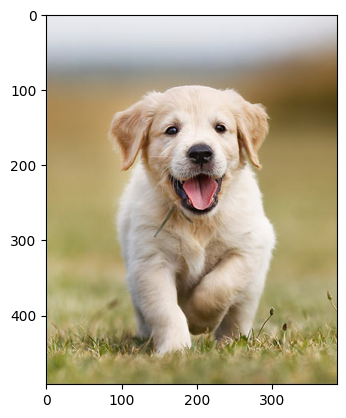

In [10]:
img_src = "/content/drive/MyDrive/DATA/HPC/image.jpg"
img=plt.imread(img_src, format=None)
plt.imshow(img)
plt.show()

GPU Gaussian 7x7 (global memory): 0.000381 seconds
GPU Gaussian 7x7 (shared memory): 0.000441 seconds


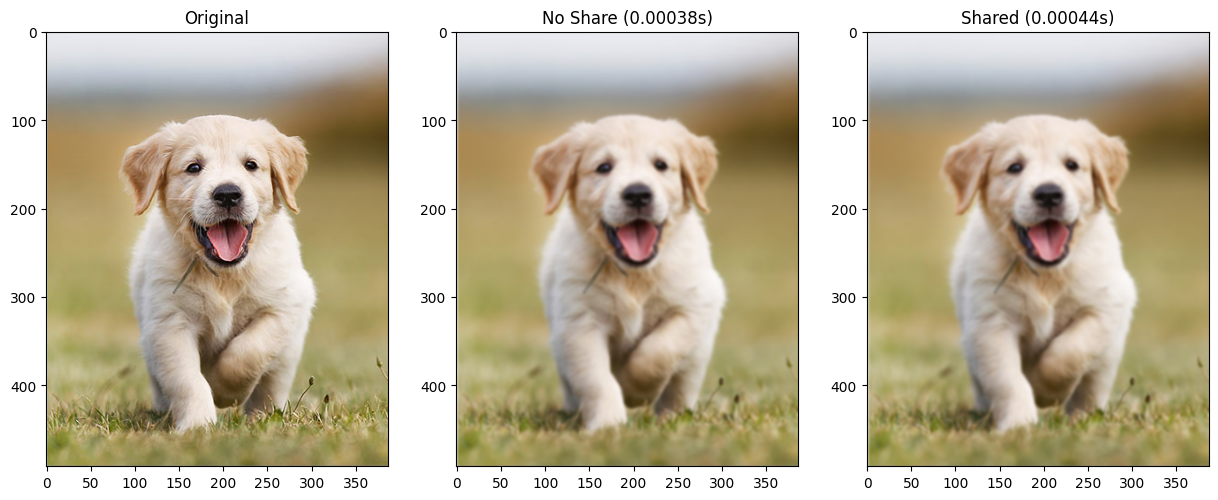

In [11]:
filt = make_gaussian_kernel(KSIZE, sigma=1.5)

blur_global, t_global = run_blur_gpu(img, gaussian_blur_global, filt)
blur_shared, t_shared = run_blur_gpu(img, gaussian_blur_shared, filt)

print(f"GPU Gaussian 7x7 (global memory): {t_global:.6f} seconds")
print(f"GPU Gaussian 7x7 (shared memory): {t_shared:.6f} seconds")

fig, axs = plt.subplots(1, 3, figsize=(15, 6))
axs[0].imshow(img);          axs[0].set_title("Original")
axs[1].imshow(blur_global);  axs[1].set_title(f"No Share ({t_global:.5f}s)")
axs[2].imshow(blur_shared);  axs[2].set_title(f"Shared ({t_shared:.5f}s)")
plt.show()

# Grayscale

In [14]:
img_c = np.ascontiguousarray(img)
filt = make_gaussian_kernel(KSIZE, sigma=1.5)

gray_image_gpu, time_gray = run_grayscale_gpu_2d(img)

blur_global, time_global = run_blur_gpu(gray_image_gpu, gaussian_blur_global, filt)
blur_shared, time_shared = run_blur_gpu(gray_image_gpu, gaussian_blur_shared, filt)


GPU Grayscale took:                    0.1836 seconds
GPU Gaussian 7x7 (global memory) took: 0.0005 seconds
GPU Gaussian 7x7 (shared memory) took: 0.0004 seconds
Hai kết quả Gaussian giống nhau: True


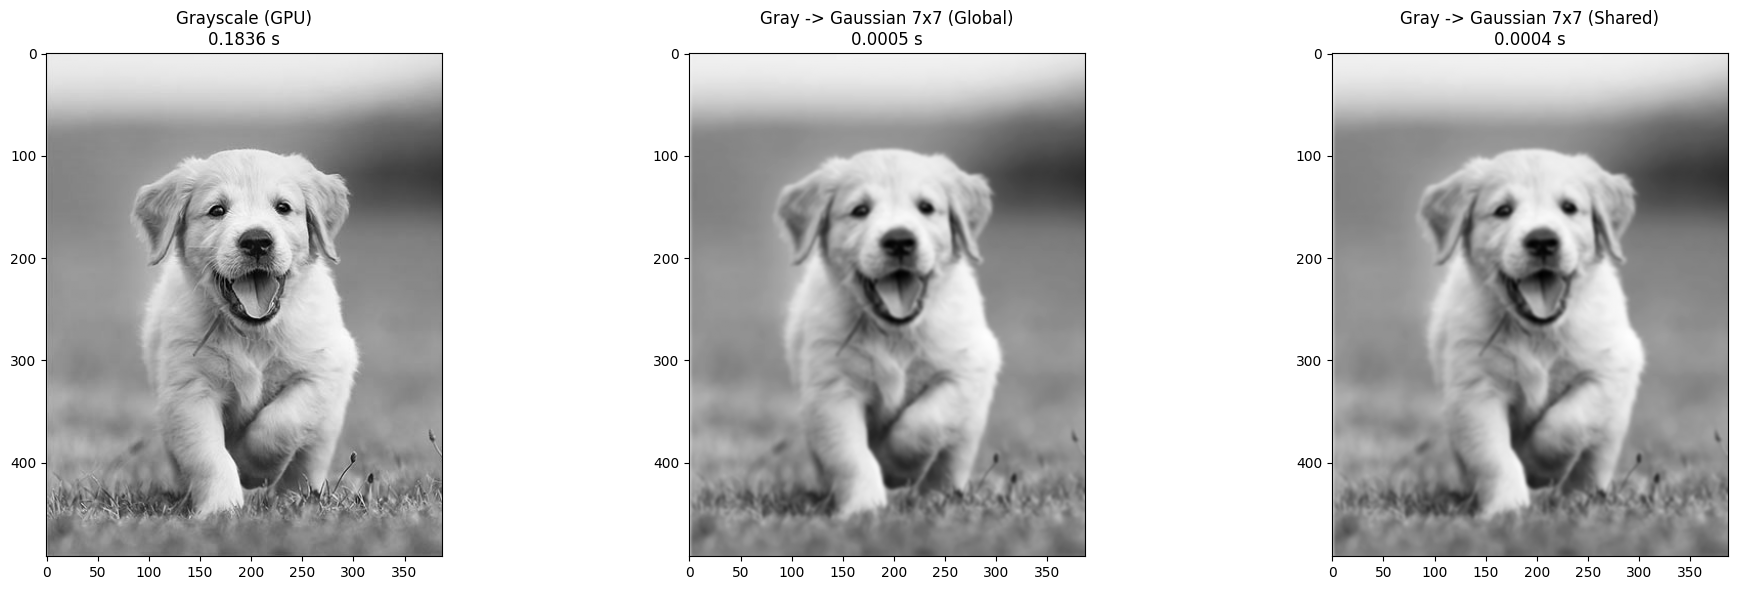

In [16]:
print(f"GPU Grayscale took:                    {time_gray:.4f} seconds")
print(f"GPU Gaussian 7x7 (global memory) took: {time_global:.4f} seconds")
print(f"GPU Gaussian 7x7 (shared memory) took: {time_shared:.4f} seconds")
print("Hai kết quả Gaussian giống nhau:", np.array_equal(blur_global, blur_shared))

fig, axs = plt.subplots(1, 3, figsize=(20, 6))
axs[0].imshow(gray_image_gpu[:, :, 0], cmap='gray')
axs[0].set_title(f'Grayscale (GPU)\n{time_gray:.4f} s')
axs[1].imshow(blur_global[:, :, 0], cmap='gray')
axs[1].set_title(f'Gray -> Gaussian 7x7 (Global)\n{time_global:.4f} s')
axs[2].imshow(blur_shared[:, :, 0], cmap='gray')
axs[2].set_title(f'Gray -> Gaussian 7x7 (Shared)\n{time_shared:.4f} s')
plt.tight_layout()
plt.show()